# IGT Reservoir with Downscaling

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from modules.IGT_Simulation import create_pulse_train, generate_single_out_current
from modules.load_MNIST import get_images_batch
from modules.One_Node_Reservoir import reconstruct_images
from modules.IGT_Reservoir_Simulation import run_reservoir

%load_ext autoreload
%autoreload 2

np.set_printoptions(threshold=np.inf)
rng = np.random.default_rng(seed=42)

In [2]:
THRESHOLD_VOLTAGE = 0
SCALE_VOLTAGE = 11
VOLTAGE = 2.5
CURVATURE = 1

TIME_RESOLUTION = 0.2
BETA = 0.56
TAU = 2.6 #ms
K = 700 #nA

# TIME_RESOLUTION = 0.2
# K = 400
# BETA = 0.65
# TAU = 3.00

NEURON_COUNT = 200

TRAIN_BATCH_SIZE = 6000
TEST_BATCH_SIZE = 1000
FLUSH_TIME=56

MAX_ITERATION = 20
LEARNING_RATE = 2

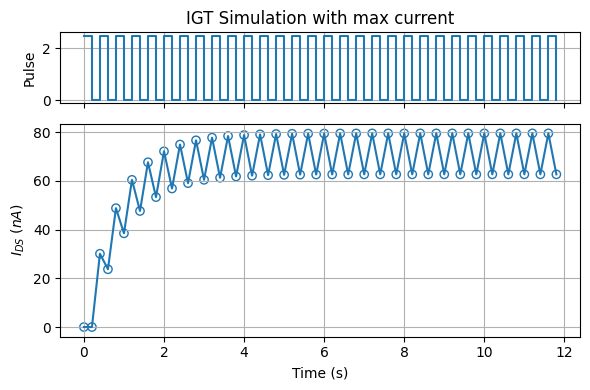

In [3]:
max_pulse = create_pulse_train(0, VOLTAGE, 1, 1, 30)

max_current = np.max(generate_single_out_current(max_pulse, K, BETA, TAU, TIME_RESOLUTION, True, "IGT Simulation with max current"))

In [4]:
zeros_flush = np.zeros((14, 1))

time_space = np.linspace(0, zeros_flush.shape[0]* TIME_RESOLUTION, zeros_flush.shape[0])

# Input weights
weight_input = rng.normal(0, 1, size=(NEURON_COUNT, 14))

# Neurons' states
current_state = np.zeros((NEURON_COUNT, 1))

# Intern weights
weight_reservoir = rng.normal(0, 1, size=(NEURON_COUNT, NEURON_COUNT))

# Readout weights
weight_output = rng.normal(0, 1, size=(10, NEURON_COUNT))

sum_matrix = np.ones_like(current_state) @ (np.ones_like(current_state).T @ abs(weight_reservoir))
sum_matrix = (lambda x: 1/x)(sum_matrix)
normalized_reservoir = sum_matrix*weight_reservoir

true_results = []
states = []

In [5]:
images, labels = get_images_batch(TRAIN_BATCH_SIZE, rng=rng)
reconstructed_images = np.array(reconstruct_images(images, max_current, K, BETA, TAU, TIME_RESOLUTION)).reshape((len(images),14,7))

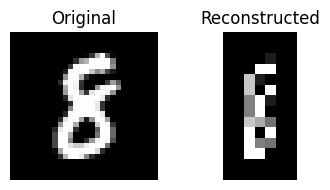

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(4, 2))

axes[0].imshow(images[0].reshape((28,28)), cmap="binary_r")
axes[0].set_title("Original")
axes[0].axis("off")  # Opcional: remove as bordas com números dos eixos

# 3ª Imagem: Método Novo
axes[1].imshow(reconstructed_images[0].reshape((14,7)), cmap="binary_r")
axes[1].set_title("Reconstructed")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [7]:
time_to_train = time.time()

weight_output, bias_output, current_state = run_reservoir(
    reconstructed_images,
    labels,
    normalized_reservoir,
    current_state,
    weight_input,
    weight_output,
    zeros_flush,
    k=K,
    beta=BETA,
    tau=TAU,
    time_resolution=TIME_RESOLUTION,
    neuron_count=NEURON_COUNT,
    binarize=False,
    dtype=np.float32
)

time_to_train = time.time() - time_to_train

-------------------------
VARIABLES:

Beta = 0.56
Tau = 2.6
K = 700

Neuron count = 200

Train batch size = 6000
Test batch size = 1000

Time to train = 9.33s

-------------------------
ACCURACY:

792 / 1000 : 79.20 %


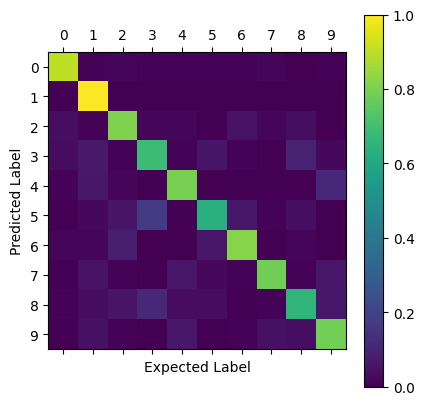

In [8]:
images_test, labels_test = get_images_batch(TEST_BATCH_SIZE, rng=rng, mode="TEST")

images_test = np.array(reconstruct_images(images_test, max_current, K, BETA, TAU, TIME_RESOLUTION)).reshape((len(images_test),14,7))

correct_predictions_count, confusion_matrix = run_reservoir(
    images_test,
    labels_test,
    normalized_reservoir,
    current_state,
    weight_input,
    weight_output,
    zeros_flush,
    k=K,
    beta=BETA,
    tau=TAU,
    time_resolution=TIME_RESOLUTION,
    bias_output=bias_output,
    mode="TEST",
    neuron_count=NEURON_COUNT,
    binarize=False,
    dtype=np.float32
)

print(f"""-------------------------
VARIABLES:
      
Beta = {BETA}
Tau = {TAU}
K = {K}

Neuron count = {NEURON_COUNT}

Train batch size = {TRAIN_BATCH_SIZE}
Test batch size = {TEST_BATCH_SIZE}

Time to train = {time_to_train:.2f}s

-------------------------
ACCURACY:
""")
print(f"{correct_predictions_count} / {len(labels_test)} : {100*(correct_predictions_count/len(labels_test)):.2f} %")

plt.matshow(confusion_matrix)
plt.colorbar()
plt.xlabel("Expected Label")
plt.ylabel("Predicted Label")
plt.xticks(np.arange(confusion_matrix.shape[0]))
plt.yticks(np.arange(confusion_matrix.shape[1]))
plt.show()